# ============================================================
# MODEL DECISION TREE DENGAN CROSS VALIDATION & FEATURE IMPORTANCE
# ============================================================

In [20]:
# Baca data
data = pd.read_csv("latihan_soal2.csv")
data

,Umur,Berat_badan,Tekanan_darah,Gula_darah_p,Status_diabetes
0,40,160,80,120,Tidak
1,35,120,70,90,Tidak
2,50,200,90,150,Ya
3,45,150,100,130,Tidak
4,55,180,85,140,Ya
5,30,110,65,80,Tidak
6,55,60,150,100,Tidak
7,65,70,200,150,Ya
8,60,80,110,100,Tidak
9,70,40,120,200,Ya


In [21]:
# Tangani missing value
data = data.dropna()  # (bisa juga diganti fillna kalau ingin isi nilai kosong)
print("Jumlah data setelah dropna:", data.shape)

Jumlah data setelah dropna: (10, 5)


In [22]:
# Pisahkan fitur dan target
X = data.drop(columns=["Status_diabetes"])
y = data["Status_diabetes"]

In [23]:
# Model Decision Tree
model = DecisionTreeClassifier(random_state=42, criterion="entropy")


In [24]:
# Cross Validation (5-fold)
scores = cross_val_score(model, X, y, cv=5)
print("\n=== Evaluasi Cross Validation (5-Fold) ===")
print("Akurasi per fold:", np.round(scores, 3))
print("Rata-rata akurasi:", round(np.mean(scores), 3))

#Latih model dengan seluruh data (agar bisa divisualisasikan)
model.fit(X, y)


=== Evaluasi Cross Validation (5-Fold) ===
Akurasi per fold: [1.  1.  0.5 1.  1. ]
Rata-rata akurasi: 0.9


D:\Belajar_ML\env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


DecisionTreeClassifier(criterion='entropy', random_state=42)

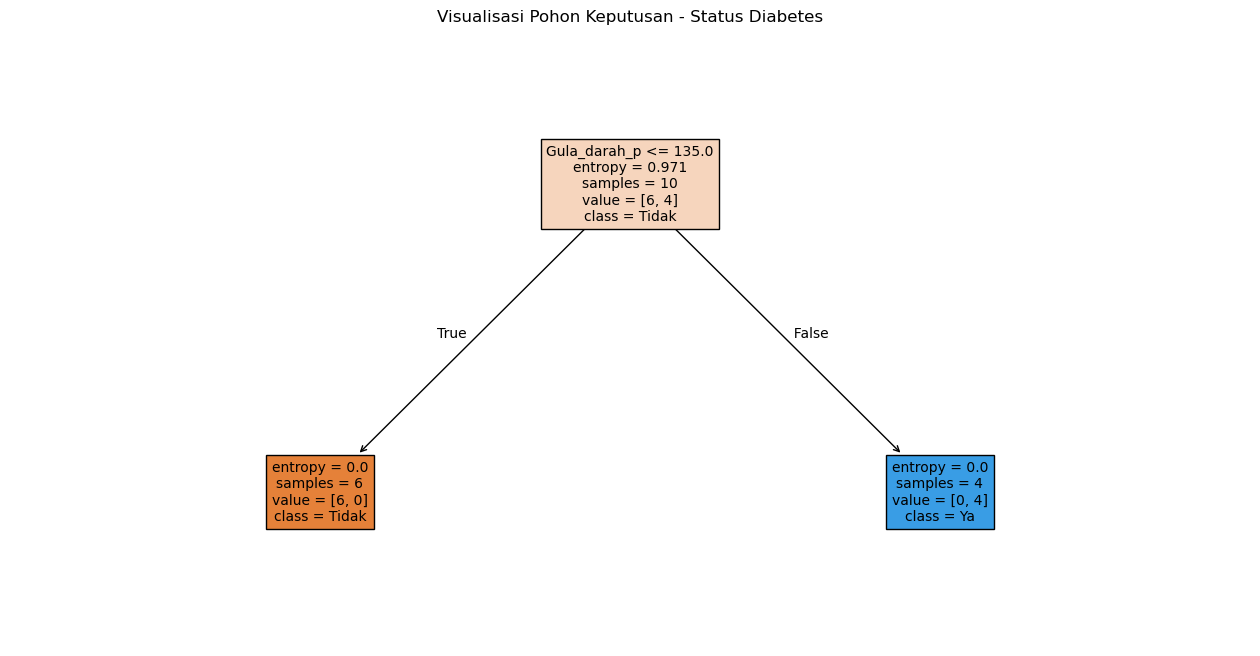

In [25]:
# isualisasi Pohon Keputusan
plt.figure(figsize=(16, 8))
plot_tree(model, filled=True, feature_names=X.columns, class_names=sorted(y.unique()), fontsize=10)
plt.title("Visualisasi Pohon Keputusan - Status Diabetes")
plt.show()

In [26]:
# feature Importance
importance = pd.DataFrame({
    "Fitur": X.columns,
    "Tingkat_Penting": model.feature_importances_
}).sort_values(by="Tingkat_Penting", ascending=False)

print("\n=== Feature Importance ===")
print(importance)


=== Feature Importance ===
           Fitur  Tingkat_Penting
3   Gula_darah_p              1.0
0           Umur              0.0
1    Berat_badan              0.0
2  Tekanan_darah              0.0


In [27]:
# Split untuk melihat contoh prediksi & evaluasi sederhana
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [28]:
print("\n=== Evaluasi pada Data Test (contoh kecil) ===")
print("Akurasi:", round(accuracy_score(y_test, y_pred), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))


=== Evaluasi pada Data Test (contoh kecil) ===
Akurasi: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]

Laporan Klasifikasi:
               precision    recall  f1-score   support

       Tidak       1.00      1.00      1.00         1
          Ya       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

